# June 2022 HRRR vs GOES RGB cloud frequency

This notebook compares hourly GOES RGB 10°C-bin cloud masks with HRRR entire-atmosphere total cloud cover for the full Colorado rectangle and a 0.5° × 0.5° East River-centered zoom. HRRR inputs include hourly f00 analyses, day-1 forecasts from the daily 00Z run, and day-2 forecasts from the preceding 00Z run. GOES has been aggregated from 5-minute pixels to hourly fractional cloud cover on the HRRR grid.

All downloading, mask generation, upscaling, and statistics are performed by standalone scripts; this notebook only reads prepared products.

In [1]:
from pathlib import Path
import numpy as np
import pandas as pd
import xarray as xr
import matplotlib.pyplot as plt
import rasterio

BASE = Path('/glade/derecho/scratch/cdalden/hrrr_goes_june2022/comparison')
COLLOCATED = BASE / 'hrrr_goes_cloud_collocated_june2022.nc'
TIMESERIES = BASE / 'hourly_domain_timeseries.csv'
STATISTICS = BASE / 'hourly_summary_statistics.csv'
DEM = Path('/glade/u/home/cdalden/goes_work/analysis/data/dem_gothic_box/usgs_3dep_dem_gothic_box.tif')
for path in (COLLOCATED, TIMESERIES, STATISTICS, DEM):
    if not path.exists():
        raise FileNotFoundError(f'Run standalone preprocessing first: {path}')
ds = xr.open_dataset(COLLOCATED)
ts = pd.read_csv(TIMESERIES, parse_dates=['time'])
stats = pd.read_csv(STATISTICS)
with rasterio.open(DEM) as src:
    elevation = src.read(1).astype(float)
    dem_x = src.transform.c + (np.arange(src.width) + 0.5) * src.transform.a
    dem_y = src.transform.f + (np.arange(src.height) + 0.5) * src.transform.e
contour_levels = np.arange(2500, 4001, 500)
ds

<xarray.Dataset> Size: 150MB
Dimensions:              (comparison: 3, time: 360, y: 163, x: 160)
Coordinates:
  * comparison           (comparison) <U12 144B 'analysis_f00' ... 'day2_00z'
  * time                 (time) datetime64[ns] 3kB 2022-06-01 ... 2022-06-30T...
    latitude             (y, x) float32 104kB ...
    longitude            (y, x) float32 104kB ...
Dimensions without coordinates: y, x
Data variables:
    hrrr_cloud_fraction  (comparison, time, y, x) float32 113MB ...
    goes_cloud_fraction  (time, y, x) float32 38MB ...
Attributes:
    title:           Hourly HRRR and upscaled GOES RGB cloud fractions for Ju...
    goes_upscaling:  GOES hourly pixel means assigned to nearest HRRR grid ce...

## Mean diurnal cloud frequency by valid UTC hour

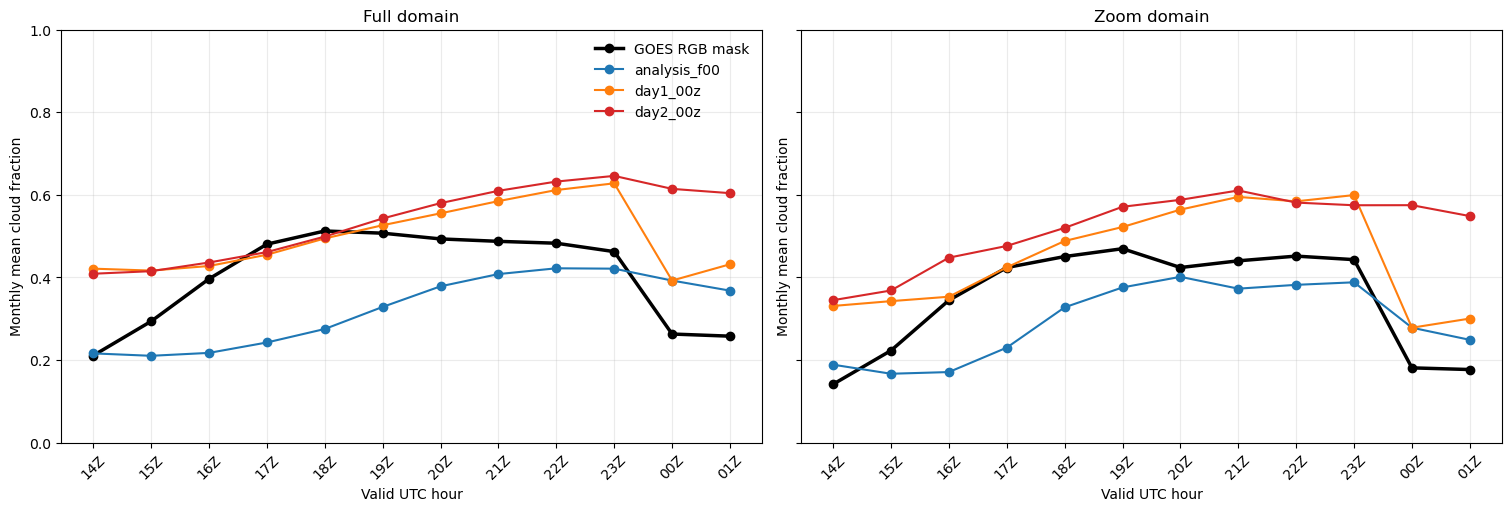

In [2]:
hour_order = list(range(14, 24)) + [0, 1]
labels = [f'{h:02d}Z' for h in hour_order]
fig, axes = plt.subplots(1, 2, figsize=(15, 5), sharey=True, constrained_layout=True)
colors = {'analysis_f00': 'tab:blue', 'day1_00z': 'tab:orange', 'day2_00z': 'tab:red'}
for ax, domain in zip(axes, ['full', 'zoom']):
    sub = ts[ts.domain == domain]
    goes = sub.groupby('utc_hour').goes_cloud_fraction.mean().reindex(hour_order)
    ax.plot(labels, goes, color='black', marker='o', lw=2.5, label='GOES RGB mask')
    for comparison, color in colors.items():
        values = sub[sub.comparison == comparison].groupby('utc_hour').hrrr_cloud_fraction.mean().reindex(hour_order)
        ax.plot(labels, values, color=color, marker='o', label=comparison)
    ax.set(title=f'{domain.capitalize()} domain', xlabel='Valid UTC hour', ylabel='Monthly mean cloud fraction', ylim=(0, 1))
    ax.tick_params(axis='x', rotation=45)
    ax.grid(alpha=0.25)
axes[0].legend(frameon=False)
plt.show()

## Domain-mean agreement and hourly bias

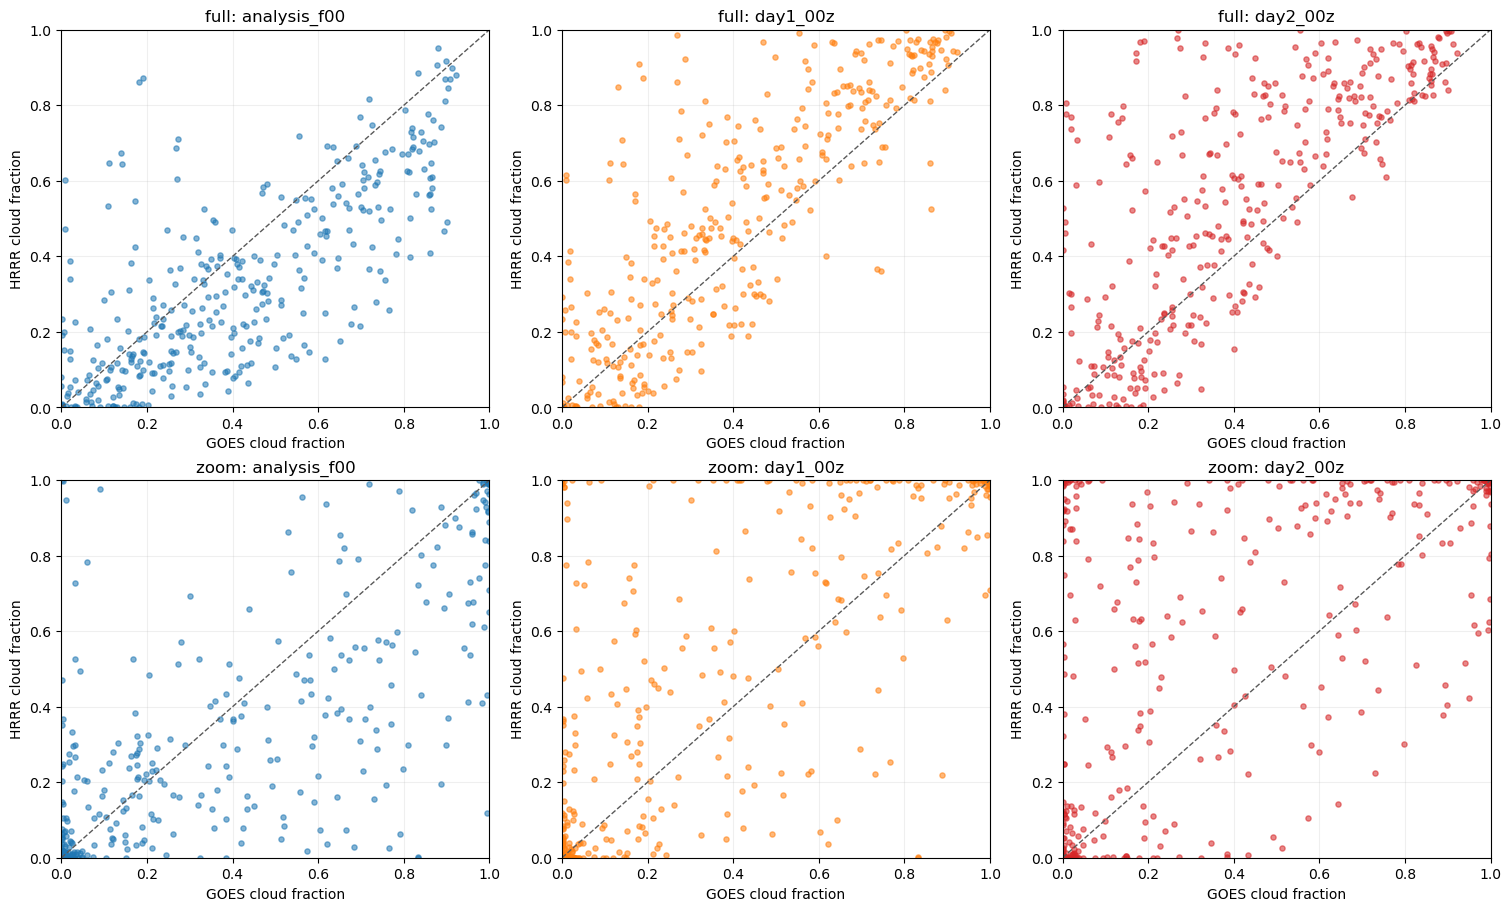

,domain,comparison,utc_hour,aggregation,n,bias,mae,rmse,correlation,accuracy,pod,far,csi,hits,misses,false_alarms,correct_negatives
1,full,analysis_f00,0,domain_mean_time_series,30,0.129504,0.226235,0.287325,0.363360,0.666667,0.500000,0.800,0.166667,2,2,8,18
3,full,analysis_f00,1,domain_mean_time_series,30,0.110292,0.205296,0.265678,0.451427,0.800000,0.750000,0.625,0.333333,3,1,5,21
5,full,analysis_f00,14,domain_mean_time_series,30,0.005200,0.086176,0.124239,0.774558,0.900000,0.666667,0.500,0.400000,2,1,2,25
7,full,analysis_f00,15,domain_mean_time_series,30,-0.083524,0.110534,0.156384,0.806842,0.966667,0.800000,0.000,0.800000,4,1,0,25
9,full,analysis_f00,16,domain_mean_time_series,30,-0.179282,0.181731,0.219532,0.840677,0.866667,0.500000,0.000,0.500000,4,4,0,22
11,full,analysis_f00,17,domain_mean_time_series,30,-0.238113,0.240298,0.272916,0.831725,0.733333,0.384615,0.000,0.384615,5,8,0,17
13,full,analysis_f00,18,domain_mean_time_series,30,-0.237356,0.239102,0.270594,0.856478,0.666667,0.333333,0.000,0.333333,5,10,0,15
15,full,analysis_f00,19,domain_mean_time_series,30,-0.178574,0.181518,0.207445,0.915843,0.766667,0.533333,0.000,0.533333,8,7,0,15
17,full,analysis_f00,20,domain_mean_time_series,30,-0.114764,0.118121,0.144330,0.945762,0.833333,0.666667,0.000,0.666667,10,5,0,15
19,full,analysis_f00,21,domain_mean_time_series,30,-0.079272,0.085865,0.114335,0.952034,0.866667,0.733333,0.000,0.733333,11,4,0,15


In [3]:
fig, axes = plt.subplots(2, 3, figsize=(15, 9), constrained_layout=True)
for row, domain in enumerate(['full', 'zoom']):
    for col, comparison in enumerate(colors):
        sub = ts[(ts.domain == domain) & (ts.comparison == comparison)]
        axes[row, col].scatter(sub.goes_cloud_fraction, sub.hrrr_cloud_fraction, s=14, alpha=0.55, color=colors[comparison])
        axes[row, col].plot([0, 1], [0, 1], '--', color='0.35', lw=1)
        axes[row, col].set(xlim=(0, 1), ylim=(0, 1), xlabel='GOES cloud fraction', ylabel='HRRR cloud fraction', title=f'{domain}: {comparison}')
        axes[row, col].grid(alpha=0.2)
plt.show()

domain_stats = stats[stats.aggregation == 'domain_mean_time_series'].copy()
domain_stats.sort_values(['domain', 'comparison', 'utc_hour']).head(12)

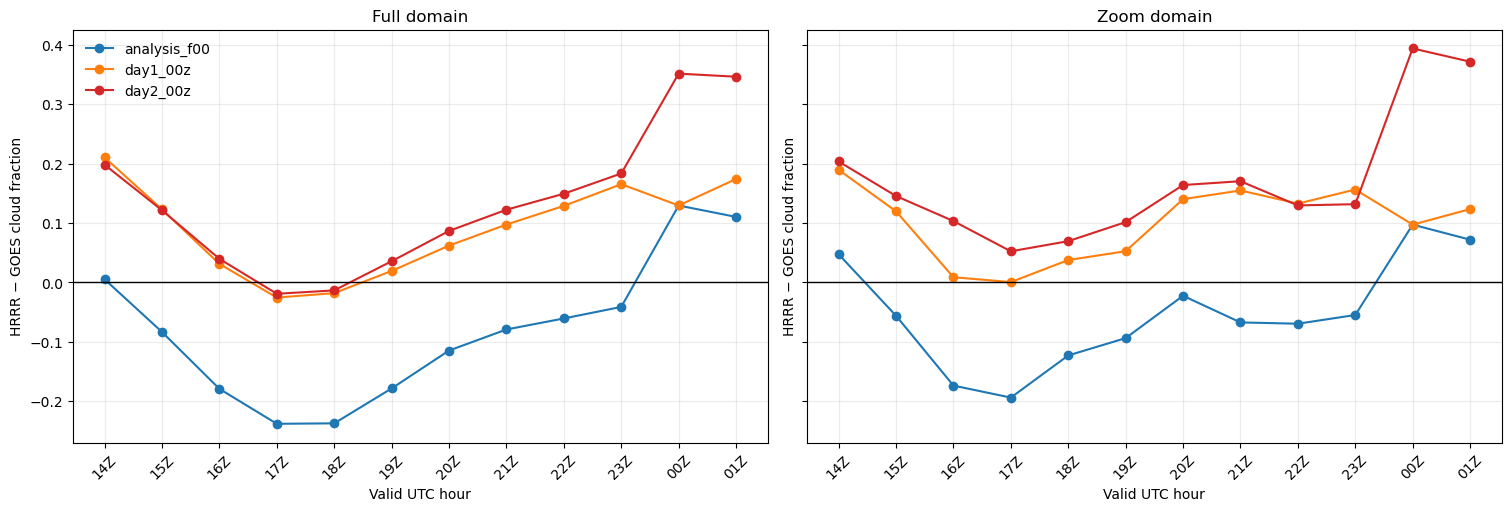

In [4]:
fig, axes = plt.subplots(1, 2, figsize=(15, 5), sharey=True, constrained_layout=True)
for ax, domain in zip(axes, ['full', 'zoom']):
    sub = domain_stats[domain_stats.domain == domain]
    for comparison, color in colors.items():
        values = sub[sub.comparison == comparison].set_index('utc_hour').bias.reindex(hour_order)
        ax.plot(labels, values, marker='o', color=color, label=comparison)
    ax.axhline(0, color='black', lw=1)
    ax.set(title=f'{domain.capitalize()} domain', xlabel='Valid UTC hour', ylabel='HRRR − GOES cloud fraction')
    ax.tick_params(axis='x', rotation=45)
    ax.grid(alpha=0.25)
axes[0].legend(frameon=False)
plt.show()

## Monthly mean cloud-frequency maps on the common HRRR grid

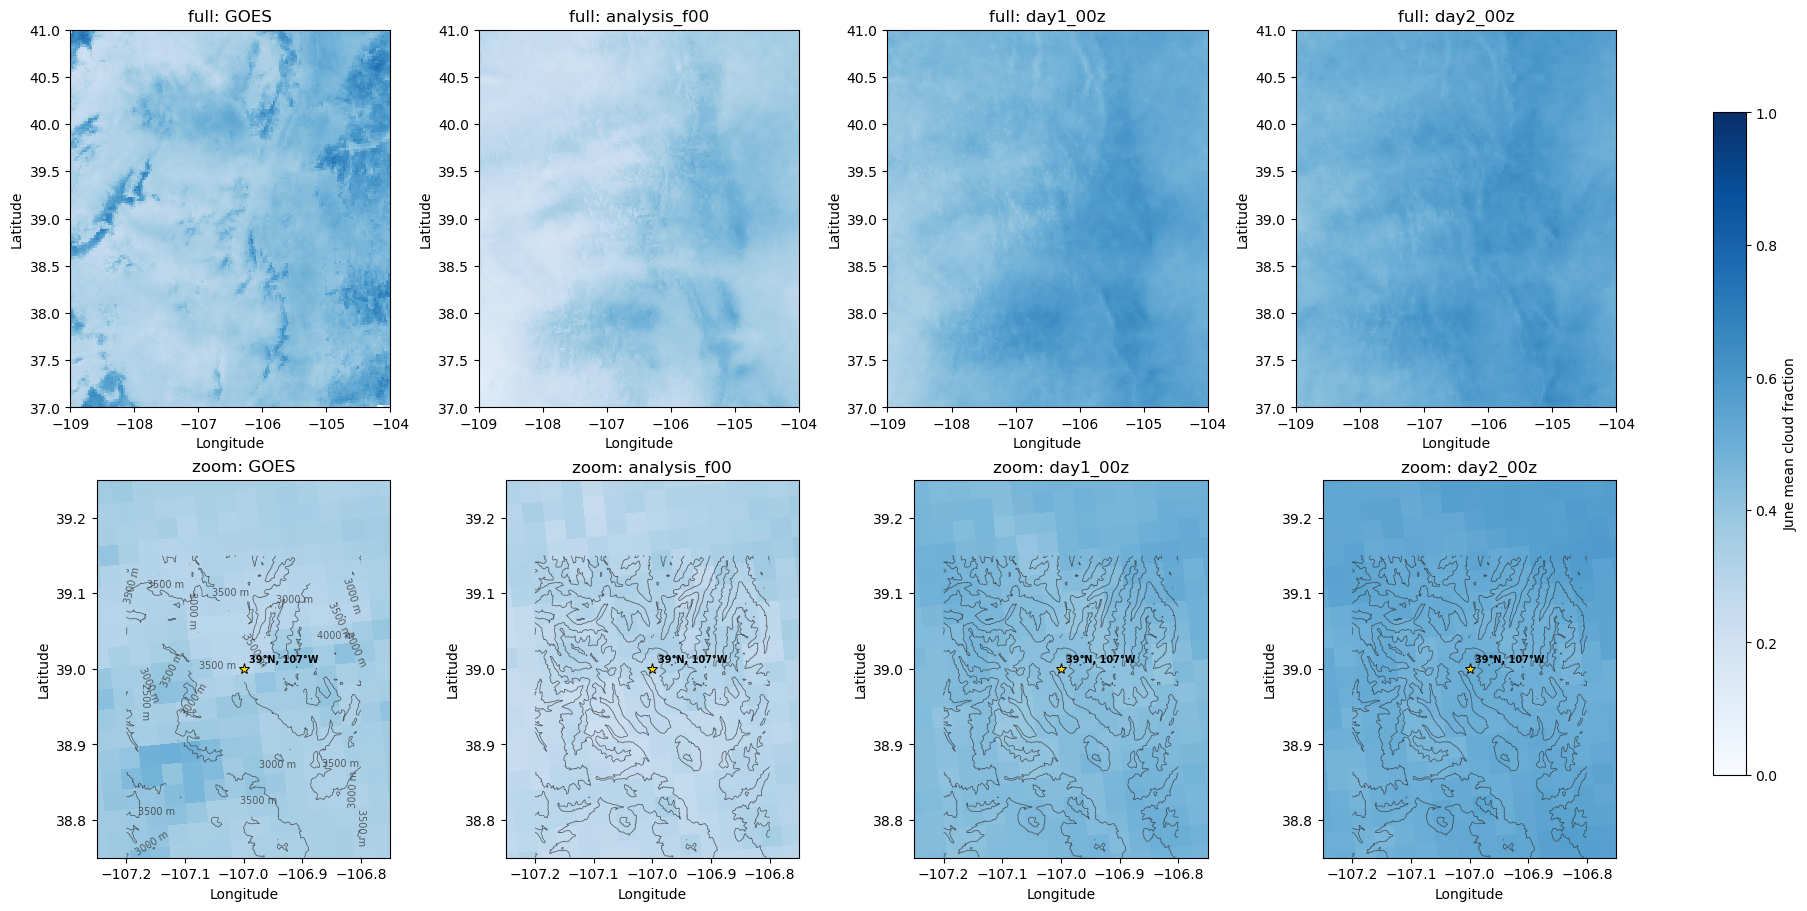

In [5]:
goes_month = ds.goes_cloud_fraction.mean('time')
hrrr_month = ds.hrrr_cloud_fraction.mean('time')
lon, lat = ds.longitude, ds.latitude
fig, axes = plt.subplots(2, 4, figsize=(18, 9), constrained_layout=True)
fields = [('GOES', goes_month)] + [(name, hrrr_month.sel(comparison=name)) for name in ds.comparison.values.astype(str)]
for row, (domain, extent) in enumerate({'full': (-109, -104, 37, 41), 'zoom': (-107.25, -106.75, 38.75, 39.25)}.items()):
    for col, (name, field) in enumerate(fields):
        mesh = axes[row, col].pcolormesh(lon, lat, field, shading='auto', vmin=0, vmax=1, cmap='Blues')
        ax = axes[row, col]
        if domain == 'zoom':
            contours = ax.contour(dem_x, dem_y, elevation, levels=contour_levels, colors='0.20', linewidths=0.55, alpha=0.75)
            if col == 0:
                ax.clabel(contours, fmt='%d m', fontsize=7, inline=True)
            ax.plot(-107.0, 39.0, marker='*', ms=8, color='gold', markeredgecolor='black', markeredgewidth=0.7, zorder=5)
            ax.annotate('39°N, 107°W', (-107.0, 39.0), xytext=(4, 5), textcoords='offset points', fontsize=7, weight='bold')
            ax.set_aspect(1 / np.cos(np.deg2rad(39.0)))
        ax.set(xlim=extent[:2], ylim=extent[2:], title=f'{domain}: {name}', xlabel='Longitude', ylabel='Latitude')
fig.colorbar(mesh, ax=axes, label='June mean cloud fraction', shrink=0.8)
plt.show()

## Summary statistics
Statistics include continuous bias/MAE/RMSE/correlation and 50%-threshold categorical accuracy, POD, FAR, and CSI for both collocated grid cells and domain-mean time series.

In [6]:
summary = (stats.groupby(['domain', 'comparison', 'aggregation'])[['bias', 'mae', 'rmse', 'correlation', 'accuracy', 'pod', 'far', 'csi']].mean().round(3))
summary

bias    mae   rmse  correlation  \
domain comparison   aggregation                                                 
full   analysis_f00 collocated_grid_cells   -0.081  0.331  0.484        0.323   
                    domain_mean_time_series -0.081  0.152  0.187        0.805   
       day1_00z     collocated_grid_cells    0.091  0.338  0.500        0.351   
                    domain_mean_time_series  0.091  0.151  0.191        0.826   
       day2_00z     collocated_grid_cells    0.133  0.354  0.515        0.353   
                    domain_mean_time_series  0.133  0.178  0.230        0.811   
zoom   analysis_f00 collocated_grid_cells   -0.053  0.235  0.377        0.510   
                    domain_mean_time_series -0.053  0.158  0.242        0.722   
       day1_00z     collocated_grid_cells    0.101  0.253  0.410        0.519   
                    domain_mean_time_series  0.101  0.191  0.295        0.675   
       day2_00z     collocated_grid_cells    0.170  0.316  0.475        0.451   
                    domain_mean_time_series  0.170  0.263  0.380        0.589   

                                             accuracy    pod    far    csi  
domain comparison   aggregation                                             
full   analysis_f00 collocated_grid_cells       0.651  0.425  0.397  0.324  
                    domain_mean_time_series     0.825  0.627  0.160  0.542  
       day1_00z     collocated_grid_cells       0.656  0.658  0.451  0.431  
                    domain_mean_time_series     0.831  0.914  0.348  0.625  
       day2_00z     collocated_grid_cells       0.639  0.704  0.457  0.437  
                    domain_mean_time_series     0.775  0.984  0.388  0.604  
zoom   analysis_f00 collocated_grid_cells       0.748  0.470  0.339  0.376  
                    domain_mean_time_series     0.822  0.589  0.183  0.503  
       day1_00z     collocated_grid_cells       0.749  0.717  0.431  0.479  
                    domain_mean_time_series     0.819  0.818  0.347  0.580  
       day2_00z     collocated_grid_cells       0.680  0.773  0.485  0.442  
                    domain_mean_time_series     0.717  0.865  0.455  0.497